# 1. CONFIGURAÇÃO E IMPORTAÇÃO

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Estilo dos gráficos
sns.set_theme(style="whitegrid")

# 2. CARREGAMENTO DOS DADOS

In [50]:
print("Iniciando Carregamento")

# Carregando o arquivo
file_path = 'atividade3 - Dataset_sint_tico_de_voos.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Arquivo '{file_path}' carregado com sucesso!")
else:
    print(f"ERRO: O arquivo '{file_path}' não foi encontrado. Faça o upload na aba de arquivos.")

# Conferindo a estrutura
print(f"Dimensões: {df.shape}")
display(df.head())
df.info()

--- Iniciando Carregamento ---
Arquivo 'atividade3 - Dataset_sint_tico_de_voos.csv' carregado com sucesso!
Dimensões: (100, 9)


,FL_DATE,OP_UNIQUE_CARRIER,TAIL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_DELAY,ARR_DELAY,DISTANCE
0,2023-01-01,AZUL,N1000,GIG,FOR,1369,7.0,32.0,4984
1,2023-01-02,SW,N1001,BSB,MIA,1986,-42.0,-38.0,4200
2,2023-01-03,LATAM,N1002,ORD,REC,1534,-30.0,21.0,1833
3,2023-01-04,AZUL,N1003,JFK,FOR,146,-39.0,52.0,2352
4,2023-01-05,UA,N1004,GIG,SFO,1734,-24.0,42.0,710


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FL_DATE            100 non-null    object 
 1   OP_UNIQUE_CARRIER  100 non-null    object 
 2   TAIL_NUM           100 non-null    object 
 3   ORIGIN             100 non-null    object 
 4   DEST               100 non-null    object 
 5   CRS_DEP_TIME       100 non-null    int64  
 6   DEP_DELAY          90 non-null     float64
 7   ARR_DELAY          90 non-null     float64
 8   DISTANCE           100 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 7.2+ KB


# 3. LIMPEZA E TRATAMENTO

In [51]:
print("\n--- Iniciando Limpeza ---")

# Quantidade de nulos
print("Nulos iniciais:\n", df.isnull().sum())

# Remoção de linhas sem informação de atraso (Variável Alvo)
# Se ARR_DELAY ou DEP_DELAY são nulos, o voo não serve para análise de pontualidade
df = df.dropna(subset=['ARR_DELAY', 'DEP_DELAY'])

print(f"Dimensões após limpeza: {df.shape}")


--- Iniciando Limpeza ---
Nulos iniciais:
 FL_DATE               0
OP_UNIQUE_CARRIER     0
TAIL_NUM              0
ORIGIN                0
DEST                  0
CRS_DEP_TIME          0
DEP_DELAY            10
ARR_DELAY            10
DISTANCE              0
dtype: int64
Dimensões após limpeza: (80, 9)


# 4. FEATURE ENGINEERING (Criação de Variáveis)

In [52]:
# 1. Conversão de Data
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# 2. Extração de Componentes de Data
df['Month'] = df['FL_DATE'].dt.month
df['DayOfWeek'] = df['FL_DATE'].dt.day_name() # Retorna o nome (Monday, Tuesday...)

# 3. Extração da Hora de Partida
# Tratamento para hora sintética (ex: 1369 -> 13h)
df['DepHour'] = (df['CRS_DEP_TIME'] // 100).astype(int)

# 4. Flag de Atraso (> 15 min)
df['flag_atraso'] = (df['ARR_DELAY'] > 15).astype(int)

# 5. Atraso Absoluto
df['ArrDelayAbs'] = df['ARR_DELAY'].abs()

# 6. Mostrando as novas colunas
display(df[['FL_DATE', 'Month', 'DayOfWeek', 'DepHour', 'flag_atraso']].head(10))

,FL_DATE,Month,DayOfWeek,DepHour,flag_atraso
0,2023-01-01,1,Sunday,13,1
1,2023-01-02,1,Monday,19,0
2,2023-01-03,1,Tuesday,15,1
3,2023-01-04,1,Wednesday,1,1
4,2023-01-05,1,Thursday,17,1
5,2023-01-06,1,Friday,18,0
6,2023-01-07,1,Saturday,4,0
7,2023-01-08,1,Sunday,19,1
8,2023-01-09,1,Monday,16,1
9,2023-01-10,1,Tuesday,6,0


# 5. ESTATÍSTICAS E ANÁLISE

In [59]:
print("\n--- Estatísticas Descritivas ---")

# Resumo estatístico
display(df[['ARR_DELAY', 'DEP_DELAY', 'DISTANCE']].describe())

# Percentual de Atrasos
pct_atraso = df['flag_atraso'].mean() * 100
print(f"\n>>> Taxa de Atrasos (> 15min): {pct_atraso:.2f}%")
print(f"\n>>> média de Atrasos da partida: {df['DEP_DELAY'].mean():.0f} minutos")


--- Estatísticas Descritivas ---


,ARR_DELAY,DEP_DELAY,DISTANCE
count,80.000000,80.000000,80.00000
mean,4.950000,10.625000,2886.20000
std,39.382866,34.089003,1431.84197
min,-103.000000,-57.000000,337.00000
25%,-24.000000,-12.000000,1906.25000
50%,4.500000,7.500000,2940.00000
75%,31.250000,36.500000,4185.75000
max,90.000000,106.000000,4984.00000



>>> Taxa de Atrasos (> 15min): 38.75%

>>> média de Atrasos da partida: 11 minutos


# 6. VISUALIZAÇÕES


--- Gerando Visualizações ---


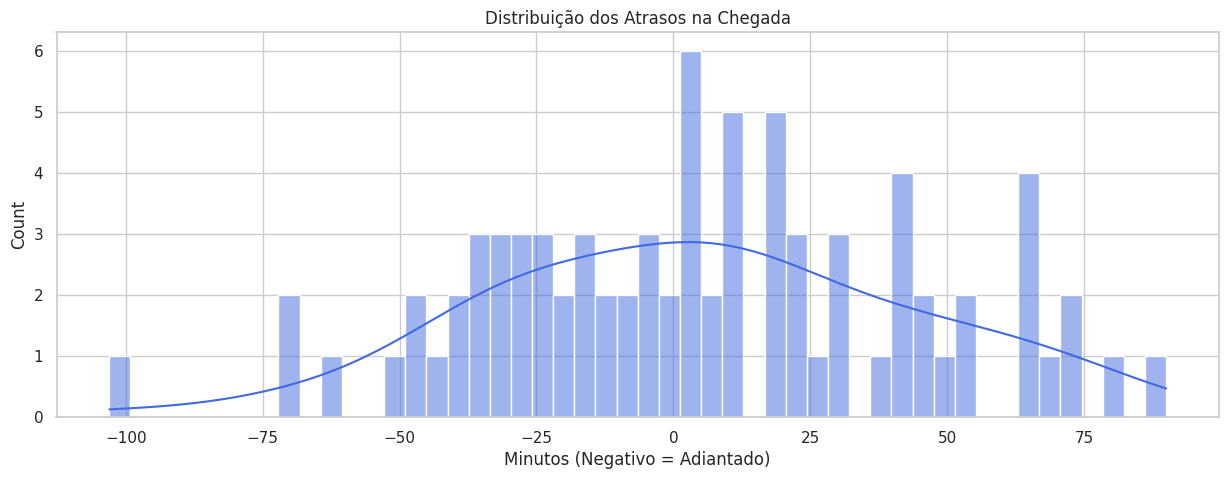

In [54]:
print("\n--- Gerando Visualizações ---")

# 1. Histograma (Distribuição)
plt.figure(figsize=(15, 5))
sns.histplot(data=df, x='ARR_DELAY', bins=50, kde=True, color='royalblue')
plt.title('Distribuição dos Atrasos na Chegada')
plt.xlabel('Minutos (Negativo = Adiantado)')
plt.show()

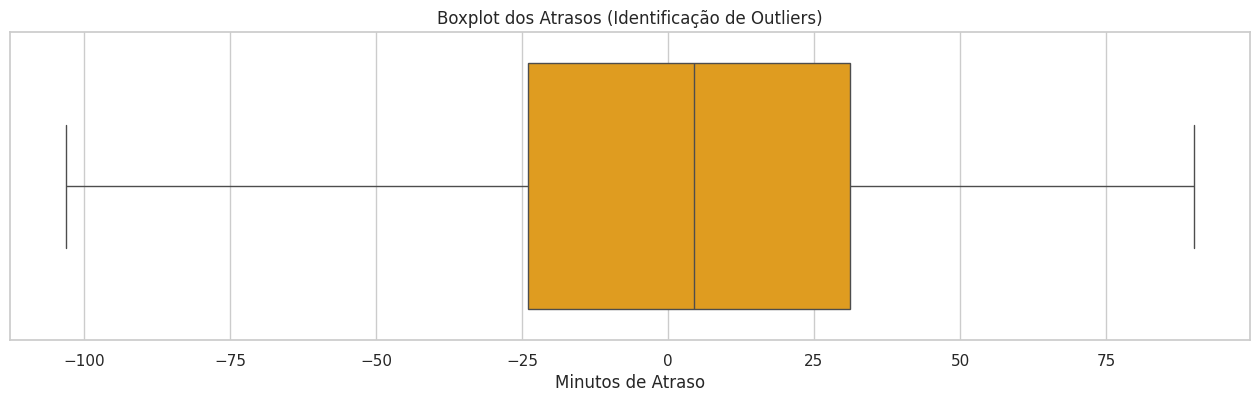

In [55]:
# 2. Boxplot (Outliers)
plt.figure(figsize=(16, 4))
sns.boxplot(x=df['ARR_DELAY'], color='orange')
plt.title('Boxplot dos Atrasos (Identificação de Outliers)')
plt.xlabel('Minutos de Atraso')
plt.show()

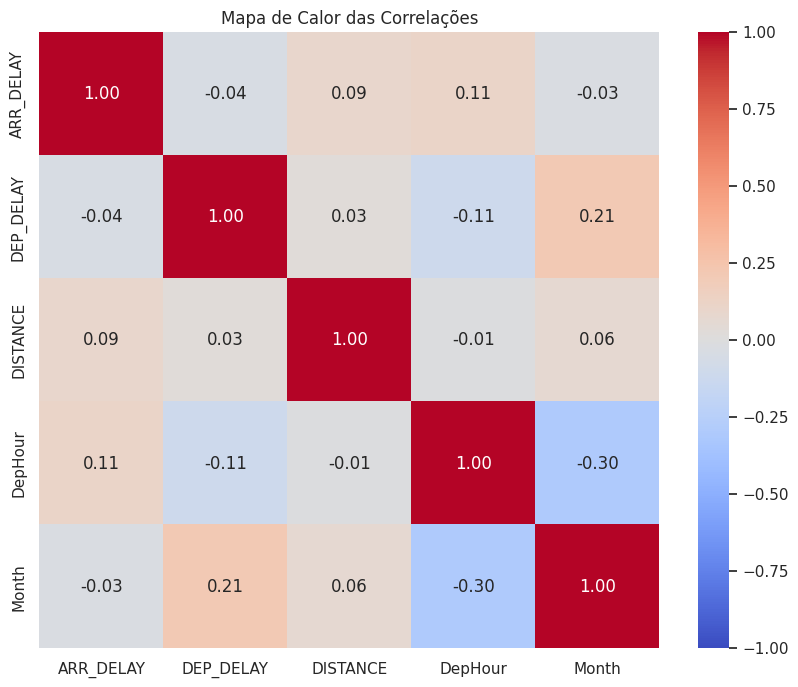

In [56]:
# 3. Heatmap (Correlações)
plt.figure(figsize=(10, 8))
cols_corr = ['ARR_DELAY', 'DEP_DELAY', 'DISTANCE', 'DepHour', 'Month']
corr_matrix = df[cols_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor das Correlações')
plt.show()

/tmp/ipython-input-2453900588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_airports.values, y=top_airports.index, palette='Reds_r')


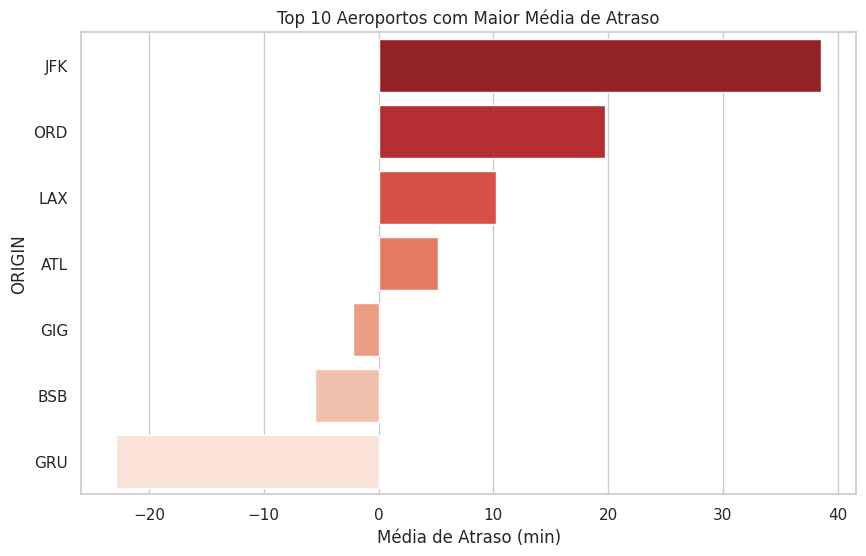

In [57]:
# 4. Top 10 Aeroportos
top_airports = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_airports.values, y=top_airports.index, palette='Reds_r')
plt.title('Top 10 Aeroportos com Maior Média de Atraso')
plt.xlabel('Média de Atraso (min)')
plt.show()

# 7. SALVAR ARQUIVO FINAL

In [58]:
df.to_csv('flight_delays_clean_v2.csv', index=False)
print("\nArquivo final salvo com sucesso!")


Arquivo final salvo com sucesso!


## Conclusões e Insights (Base Amostral: 100 Voos)

A Análise Exploratória revelou características peculiares neste conjunto de dados sintéticos, distintas de um cenário real de aviação:

- **Taxa de Atrasos Elevada:**
  Identificamos que **38,75%** dos voos sofreram atrasos superiores a 15 minutos na chegada. Este índice é significativamente alto para padrões operacionais normais.

- **Médias Gerais de Atraso:**
  Após a análise detalhada das estatísticas descritivas, percebe-se que a média de atraso na partida (`DEP_DELAY`) é de aproximadamente **11 minutos** (10.6 min), enquanto a média na chegada (`ARR_DELAY`) cai para cerca de **5 minutos**.

- **Anomalia de Correlação (Insight Técnico):**
O heatmap mostrou praticamente nenhuma correlação entre horário de Partida e de Chegada (coeficiente de -0.04).

- **Gargalos Operacionais:**
  A análise segmentada apontou o aeroporto **JFK** como o mais crítico, com média de atraso na chegada superior a **38 minutos**.
  Em contraste, o aeroporto **GIG** apresentou média negativa, indicando tendência de adiantamento.